In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [194]:
df = pd.read_csv('playerstatistics.csv')
df.info()


/var/folders/r0/q0y6gsw57js1fng83nx115q40000gn/T/ipykernel_40161/2185362428.py:1: DtypeWarning:

Columns (4,6,7,8,10,11,15) have mixed types. Specify dtype option on import or set low_memory=False.



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657595 entries, 0 to 1657594
Data columns (total 35 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   firstName                1657361 non-null  object 
 1   lastName                 1657357 non-null  object 
 2   personId                 1657550 non-null  float64
 3   gameId                   1657595 non-null  int64  
 4   gameDateTimeEst          1653867 non-null  object 
 5   playerteamCity           1657427 non-null  object 
 6   playerteamName           1653867 non-null  object 
 7   opponentteamCity         1653699 non-null  object 
 8   opponentteamName         1653867 non-null  object 
 9   gameType                 1657545 non-null  object 
 10  gameLabel                96782 non-null    object 
 11  gameSubLabel             6497 non-null     object 
 12  seriesGameNumber         135048 non-null   float64
 13  win                      1653857 non-null 

In [195]:
df.head()

,firstName,lastName,personId,gameId,gameDateTimeEst,playerteamCity,playerteamName,opponentteamCity,opponentteamName,gameType,...,threePointersPercentage,freeThrowsAttempted,freeThrowsMade,freeThrowsPercentage,reboundsDefensive,reboundsOffensive,reboundsTotal,foulsPersonal,turnovers,plusMinusPoints
0,Kris,Dunn,1627739.0,22500827,2026-02-22 21:00:00,LA,Clippers,Orlando,Magic,Regular Season,...,0.0,4.0,3.0,0.75,4.0,1.0,5.0,2.0,1.0,-8.0
1,Derrick,Jones Jr.,1627884.0,22500827,2026-02-22 21:00:00,LA,Clippers,Orlando,Magic,Regular Season,...,0.0,0.0,0.0,0.00,0.0,3.0,3.0,1.0,1.0,2.0
2,Jonathan,Isaac,1628371.0,22500827,2026-02-22 21:00:00,Orlando,Magic,LA,Clippers,Regular Season,...,0.0,2.0,1.0,0.50,2.0,2.0,4.0,1.0,0.0,-4.0
3,Jevon,Carter,1628975.0,22500827,2026-02-22 21:00:00,Orlando,Magic,LA,Clippers,Regular Season,...,0.0,0.0,0.0,0.00,1.0,1.0,2.0,2.0,0.0,1.0
4,Wendell,Carter Jr.,1628976.0,22500827,2026-02-22 21:00:00,Orlando,Magic,LA,Clippers,Regular Season,...,0.0,3.0,3.0,1.00,10.0,4.0,14.0,3.0,5.0,2.0


In [196]:
df.columns

Index(['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst',
       'playerteamCity', 'playerteamName', 'opponentteamCity',
       'opponentteamName', 'gameType', 'gameLabel', 'gameSubLabel',
       'seriesGameNumber', 'win', 'home', 'numMinutes', 'points', 'assists',
       'blocks', 'steals', 'fieldGoalsAttempted', 'fieldGoalsMade',
       'fieldGoalsPercentage', 'threePointersAttempted', 'threePointersMade',
       'threePointersPercentage', 'freeThrowsAttempted', 'freeThrowsMade',
       'freeThrowsPercentage', 'reboundsDefensive', 'reboundsOffensive',
       'reboundsTotal', 'foulsPersonal', 'turnovers', 'plusMinusPoints'],
      dtype='object')

In [197]:
columns_to_keep = [
    "firstName",
    "lastName",
    "personId",
    "playerteamName",
    "gameDateTimeEst",
    "gameType",
    "win",
    "points",
    "assists",
    "reboundsTotal",
    "numMinutes",
    "threePointersPercentage",
    "threePointersMade",
    "fieldGoalsPercentage",
    "fieldGoalsMade",
    "freeThrowsPercentage",
    "freeThrowsMade",
    "turnovers",
    "blocks",
    "steals",
    "gameId"
]

df = df[columns_to_keep]

df["playerName"] = df["firstName"].str.strip() + " " + df["lastName"].str.strip()

In [198]:
df["numMinutes"] = pd.to_numeric(df["numMinutes"], errors="coerce")
df["points"] = pd.to_numeric(df["points"], errors="coerce")
df["win"] = pd.to_numeric(df["win"], errors="coerce")

In [199]:
df.isnull().sum()

firstName                     234
lastName                      238
personId                       45
playerteamName               3728
gameDateTimeEst              3728
gameType                       50
win                          3738
points                       1718
assists                      1718
reboundsTotal                1718
numMinutes                 169310
threePointersPercentage      1718
threePointersMade            1718
fieldGoalsPercentage         1718
fieldGoalsMade               1718
freeThrowsPercentage         1718
freeThrowsMade               1718
turnovers                    1718
blocks                       1718
steals                       1718
gameId                          0
playerName                    238
dtype: int64

In [200]:
must_have = ["gameType", "playerteamName", "points", "win", "personId"]
df = df.dropna(subset=must_have)

df = df[df["numMinutes"] >= 10] #filtering out players who played less than 10 minutes

#Use this code if you want to restrict the dataset to the modern era (2010 and later)
df["gameDateTimeEst"] = pd.to_datetime(df["gameDateTimeEst"], errors="coerce")
df = df[df["gameDateTimeEst"].dt.year >= 2010]

In [201]:
df["season_year"] = pd.to_datetime(df["gameDateTimeEst"]).dt.year

regular_season = df[df["gameType"] == "Regular Season"].copy()
playoffs = df[df["gameType"] == "Playoffs"].copy()

#defining superstars
season_avg = (
    regular_season
    .groupby(["personId", "playerName", "season_year"])
    .agg(
        ppg=("points", "mean"),
        games_played=("gameId", "nunique")
    )
    .reset_index()
)

# Require BOTH 30+ PPG AND at least 50 games
superstar_ids = season_avg[
    (season_avg["ppg"] >= 30) &
    (season_avg["games_played"] >= 50)
]["personId"].unique().tolist()

print("Number of superstars:", len(superstar_ids))

superstar_games = regular_season[
    regular_season["personId"].isin(superstar_ids)
].copy()

#filtering the regular season dataset to only include games played by superstars
superstar_games["playerName"].unique()

Number of superstars: 9


array(['Luka Doncic', 'LeBron James', 'James Harden', 'Kevin Durant',
       'Joel Embiid', 'Shai Gilgeous-Alexander', 'Stephen Curry',
       'Giannis Antetokounmpo', 'Damian Lillard'], dtype=object)

In [202]:
len(superstar_ids)

9

In [203]:
#Calculating the variability of points scored by each superstar across their games

player_variability = (
    superstar_games
    .groupby(["personId", "playerName", "playerteamName", "season_year"])["points"]
    .std()
    .reset_index()
)

player_variability.rename(columns={"points": "points_std"}, inplace=True)


#Average points scored by each superstar
player_mean = (
    superstar_games
    .groupby(["personId", "playerName"])["points"]
    .mean()
    .reset_index()
)

player_stats = pd.merge(player_variability, player_mean,
                        on=["personId", "playerName"])




In [204]:
#Computing Team Winning Percentage
team_win_pct = (
    regular_season
    .groupby("playerteamName")["win"]
    .mean()
    .reset_index()
)

team_win_pct.rename(columns={"win": "win_pct"}, inplace=True)


#Measure Playoff Advancement
playoff_games_count = (
    playoffs
    .groupby(["playerteamName", "season_year"])["gameId"]
    .nunique()
    .reset_index(name = "playoff_games")
)
playoff_games_count.rename(columns={"gameId": "playoff_games"}, inplace=True)


#Merging all stats together
merged = pd.merge(player_stats,
                  team_win_pct,
                  left_on="playerteamName",
                  right_on="playerteamName",
                  how="left")

merged = pd.merge(merged,
                  playoff_games_count,
                  on=["playerteamName", "season_year"],
                  how="left")

merged["playoff_games"] = merged["playoff_games"].fillna(0)

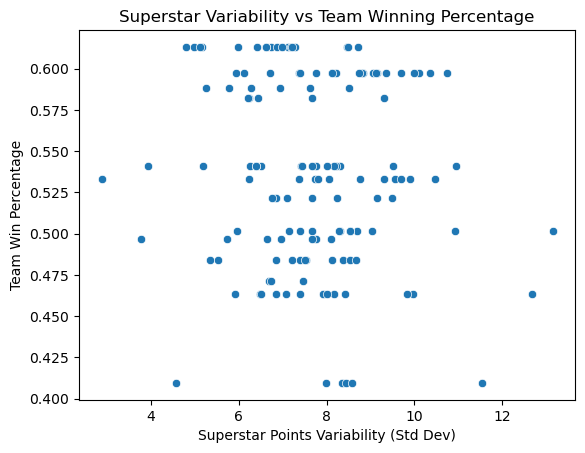

In [205]:
##Visualizations

#Variability vs Win Percentage
plt.figure()
sns.scatterplot(data=merged,
                x="points_std",
                y="win_pct")

plt.xlabel("Superstar Points Variability (Std Dev)")
plt.ylabel("Team Win Percentage")
plt.title("Superstar Variability vs Team Winning Percentage")
plt.show()

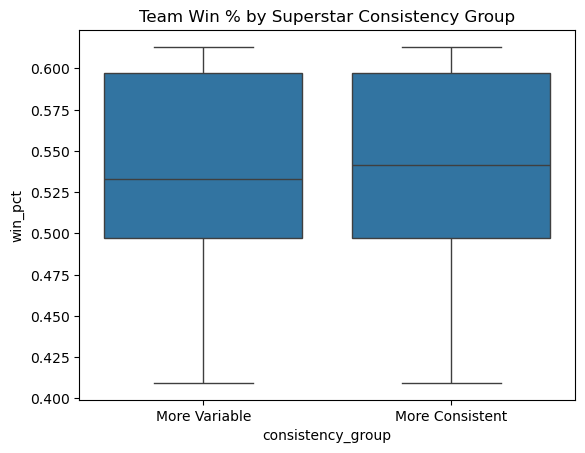

In [206]:
#Comparing High vs Low Variability Groups
median_var = merged["points_std"].median()

merged["consistency_group"] = np.where(
    merged["points_std"] <= median_var,
    "More Consistent",
    "More Variable"
)

sns.boxplot(data=merged,
            x="consistency_group",
            y="win_pct")

plt.title("Team Win % by Superstar Consistency Group")
plt.show()

In [207]:
pip install plotly


Note: you may need to restart the kernel to use updated packages.


In [208]:
#Variability vs Playoff Advancement

import plotly.express as px
fig = px.scatter(
    merged,
    x="points_std",
    y="playoff_games",
    hover_name="playerName",   # This adds name on hover
    hover_data={
        "win_pct": True,
        "points_std": True,
        "playoff_games": True
    },
    title="Superstar Variability vs Playoff Advancement"
)

fig.update_layout(
    xaxis_title="Superstar Points Variability (Std Dev)",
    yaxis_title="Number of Playoff Games"
)

fig.show()